In [1]:
import numpy as np 
import pandas as pd

In [4]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3 * X[:, 0]**2 + 0.05 * np.random.randn(100)

# Create a DataFrame instance, then assign columns
df = pd.DataFrame()
df['X'] = X.reshape(100)
df['y'] = y

df.head()

,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986


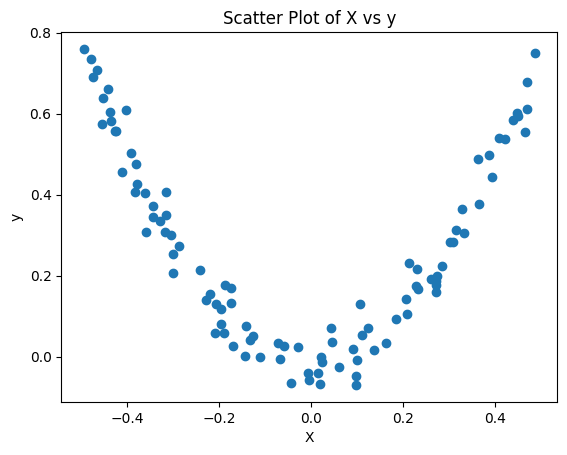

In [5]:
import matplotlib.pyplot as plt
plt.scatter(df['X'], df['y'])
plt.xlabel('X')
plt.ylabel('y')
plt.title('Scatter Plot of X vs y')
plt.show()

In [7]:
df['pred_1'] = df['y'].mean()
df.head()

,X,y,pred_1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458


In [9]:
df['error_1'] = df['y'] - df['pred_1']
df.head()

,X,y,pred_1,error_1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528


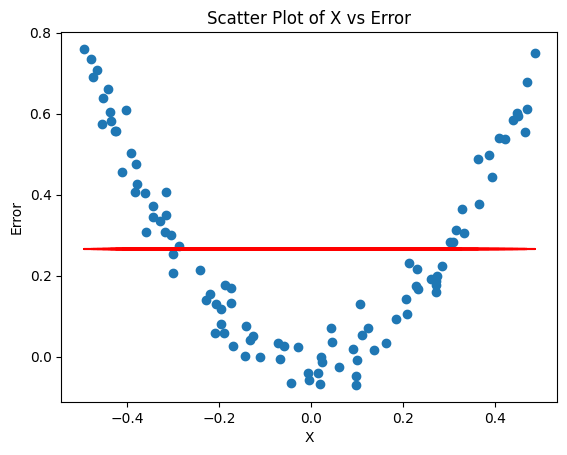

In [11]:
plt.scatter(df['X'], df['y'])
plt.plot(df['X'], df['pred_1'], color='red', label='Prediction')
plt.xlabel('X')
plt.ylabel('Error')
plt.title('Scatter Plot of X vs Error')
plt.show()

[Text(0.4090909090909091, 0.9166666666666666, 'x[0] <= -0.36\nsquared_error = 0.056\nsamples = 100\nvalue = 0.0'),
 Text(0.18181818181818182, 0.75, 'x[0] <= -0.43\nsquared_error = 0.012\nsamples = 18\nvalue = 0.309'),
 Text(0.29545454545454547, 0.8333333333333333, 'True  '),
 Text(0.09090909090909091, 0.5833333333333334, 'squared_error = 0.004\nsamples = 9\nvalue = 0.395'),
 Text(0.2727272727272727, 0.5833333333333334, 'squared_error = 0.005\nsamples = 9\nvalue = 0.222'),
 Text(0.6363636363636364, 0.75, 'x[0] <= 0.322\nsquared_error = 0.04\nsamples = 82\nvalue = -0.068'),
 Text(0.5227272727272727, 0.8333333333333333, '  False'),
 Text(0.45454545454545453, 0.5833333333333334, 'x[0] <= -0.235\nsquared_error = 0.016\nsamples = 67\nvalue = -0.142'),
 Text(0.36363636363636365, 0.4166666666666667, 'squared_error = 0.003\nsamples = 12\nvalue = 0.041'),
 Text(0.5454545454545454, 0.4166666666666667, 'x[0] <= 0.211\nsquared_error = 0.009\nsamples = 55\nvalue = -0.182'),
 Text(0.45454545454545453

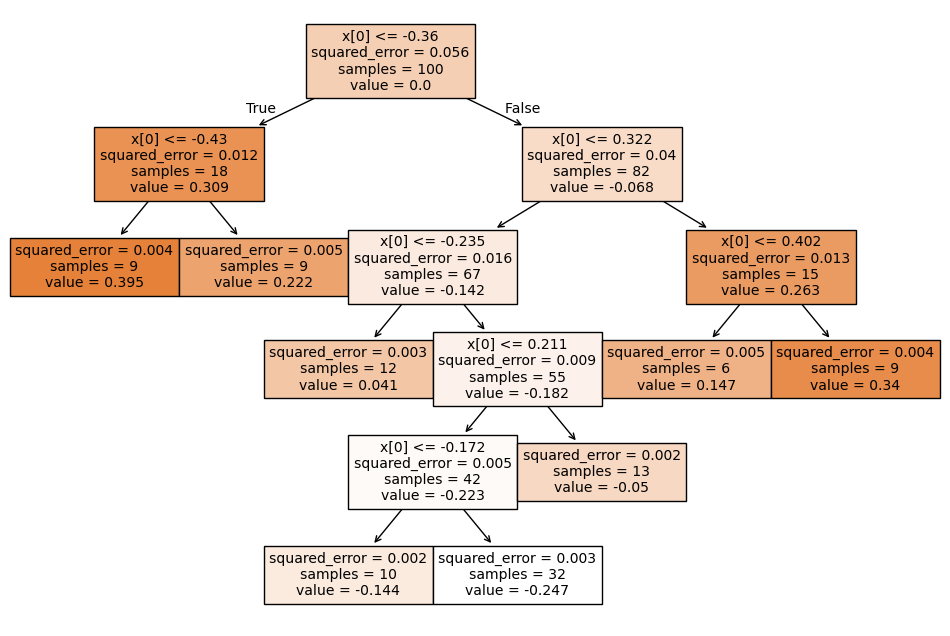

In [14]:
from sklearn.tree import DecisionTreeRegressor
model_1 = DecisionTreeRegressor(max_leaf_nodes=8)
model_1.fit(df[['X']], df['error_1'])
df['pred_2'] = model_1.predict(df[['X']])
df.head()

from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8))
plot_tree(model_1, filled=True) 

In [18]:
# generating X-test
from sklearn import tree


X_test = np.linspace(-0.5, 0.5, 500)
y_pred = 0.265458 + model_1.predict(X_test.reshape(500, 1))

/Users/I578070/Desktop/100DaysML/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Scatter Plot of X vs y with Prediction')

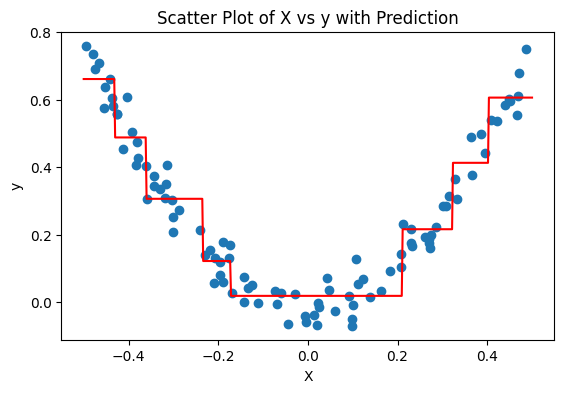

In [22]:
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.scatter(df['X'], df['y'], label='Data Points')
plt.plot(X_test, y_pred, color='red', label='Prediction')
plt.xlabel('X') 
plt.ylabel('y')
plt.title('Scatter Plot of X vs y with Prediction')

In [24]:
# Continue boosting process till model_5 (without changing previous cells)

# Current ensemble after model_1
# pred_1: initial mean prediction
# pred_2: correction from model_1 trained on error_1

df['ensemble_2'] = df['pred_1'] + df['pred_2']
df['error_2'] = df['y'] - df['ensemble_2']

# model_2 learns error_2
model_2 = DecisionTreeRegressor(max_leaf_nodes=8, random_state=42)
model_2.fit(df[['X']], df['error_2'])
df['pred_3'] = model_2.predict(df[['X']])

df['ensemble_3'] = df['ensemble_2'] + df['pred_3']
df['error_3'] = df['y'] - df['ensemble_3']

# model_3 learns error_3
model_3 = DecisionTreeRegressor(max_leaf_nodes=8, random_state=42)
model_3.fit(df[['X']], df['error_3'])
df['pred_4'] = model_3.predict(df[['X']])

df['ensemble_4'] = df['ensemble_3'] + df['pred_4']
df['error_4'] = df['y'] - df['ensemble_4']

# model_4 learns error_4
model_4 = DecisionTreeRegressor(max_leaf_nodes=8, random_state=42)
model_4.fit(df[['X']], df['error_4'])
df['pred_5'] = model_4.predict(df[['X']])

df['ensemble_5'] = df['ensemble_4'] + df['pred_5']
df['error_5'] = df['y'] - df['ensemble_5']

# model_5 learns error_5
model_5 = DecisionTreeRegressor(max_leaf_nodes=8, random_state=42)
model_5.fit(df[['X']], df['error_5'])
df['pred_6'] = model_5.predict(df[['X']])

# Final prediction after 5 models
# (initial mean + model_1 + model_2 + model_3 + model_4 + model_5)
df['final_pred_5_models'] = df['ensemble_5'] + df['pred_6']

# Use feature-name consistent test frame to avoid sklearn warnings
X_test_df = pd.DataFrame({'X': X_test})

# Test-curve prediction after 5 models
y_pred_5_models = (
    df['y'].mean()
    + model_1.predict(X_test_df)
    + model_2.predict(X_test_df)
    + model_3.predict(X_test_df)
    + model_4.predict(X_test_df)
    + model_5.predict(X_test_df)
)

print('Mean absolute error after each stage:')
print('After model_1:', np.mean(np.abs(df['error_2'])))
print('After model_2:', np.mean(np.abs(df['error_3'])))
print('After model_3:', np.mean(np.abs(df['error_4'])))
print('After model_4:', np.mean(np.abs(df['error_5'])))
print('After model_5:', np.mean(np.abs(df['y'] - df['final_pred_5_models'])))

df[['X', 'y', 'pred_1', 'pred_2', 'pred_3', 'pred_4', 'pred_5', 'pred_6', 'final_pred_5_models']].head()

Mean absolute error after each stage:
After model_1: 0.04715091503257493
After model_2: 0.03775975298705753
After model_3: 0.0316367129324009
After model_4: 0.02608440239852818
After model_5: 0.023027074238340082


,X,y,pred_1,pred_2,pred_3,pred_4,pred_5,pred_6,final_pred_5_models
0,-0.125460,0.051573,0.265458,-0.247139,-0.003999,-0.001231,0.001707,0.000628,0.015425
1,0.450714,0.594480,0.265458,0.340426,-0.008361,-0.005914,0.001707,-0.001266,0.592050
2,0.231994,0.166052,0.265458,-0.049674,-0.008361,-0.019275,0.001707,-0.001266,0.188590
3,0.098658,-0.070178,0.265458,-0.247139,-0.038130,-0.001231,0.001707,-0.040144,-0.059479
4,-0.343981,0.343986,0.265458,0.040506,-0.003999,-0.001231,0.035161,0.000628,0.336523


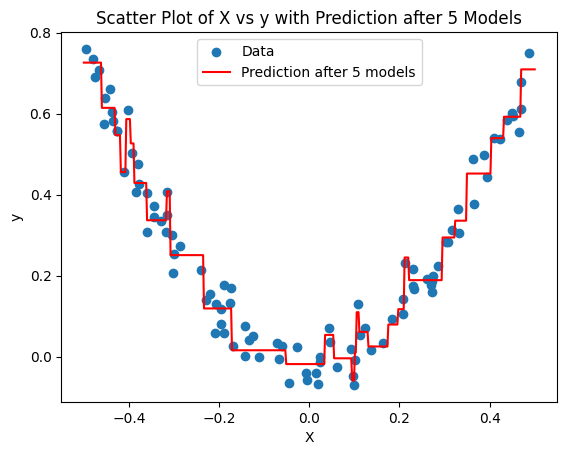

In [25]:
plt.scatter(df['X'], df['y'], label='Data'  )
plt.plot(X_test, y_pred_5_models, color='red', label='Prediction after 5 models')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Scatter Plot of X vs y with Prediction after 5 Models')
plt.legend()
plt.show()